# US Visa Prediction — Feature Engineering & Model Training




## PHASE 1: SETUP & LOADING

In [2]:
# ==============================================================================
# PHASE 1: SETUP & LOADING
# ==============================================================================

# 1.1 Import core libraries
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings for clean notebook execution
warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)

# 1.2 Load raw dataset
DATA_PATH = "/content/visa_dataset.csv"
df = pd.read_csv(DATA_PATH)

# 1.3 Initial Verification
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print(f"Total Duplicates: {df.duplicated().sum()}\n")

print("--- Missing Values Check ---")
print(df.isnull().sum())

print("\n--- Data Types & Memory Usage ---")
df.info()

print("\n--- First 5 Rows ---")
display(df.head())

Dataset Shape: 25480 rows, 12 columns

Total Duplicates: 0

--- Missing Values Check ---
case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

--- Data Types & Memory Usage ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_est

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


**Short Insight**
- The raw US Visa dataset has been successfully loaded into a Pandas DataFrame. The initial records are displayed to verify that the data was imported correctly.

## PHASE 2: DATA CLEANING

In [3]:
# ==============================================================================
# PHASE 2: DATA CLEANING
# ==============================================================================

# 2.1 Drop Irrelevant Columns (case_id has 100% unique values with zero predictive power)
if "case_id" in df.columns:
    df.drop(columns=["case_id"], inplace=True)
    print(" Dropped 'case_id' successfully.")

# ==============================================================================

# 2.2 Defensive check & handling for Missing Values
null_count = df.isnull().sum().sum()
if null_count > 0:
    # If missing values exist, drop or impute
    df.dropna(inplace=True)
    print(f"Dropped {null_count} missing values.")
else:
    print("No missing values detected.")

# ==============================================================================

# 2.3 Check & remove duplicate records
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Removed {duplicate_count} duplicate rows.")
else:
    print("No duplicate records found.")

# Verify cleaned dataset dimensions
print(f"\nCleaned Data Shape: {df.shape[0]} rows, {df.shape[1]} columns")
display(df.head(3))

# ==============================================================================


 Dropped 'case_id' successfully.
No missing values detected.
No duplicate records found.

Cleaned Data Shape: 25480 rows, 11 columns


,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied


### Insight
- High-cardinality identifier case_id was permanently dropped to eliminate noise and prevent data leakage, reducing feature count from 12 to 11.

- The dataset retains all 25,480 complete, non-duplicate records, establishing a clean and reliable baseline for feature engineering in Phase 3.

## Phase 3: Feature Engineering

In [4]:

# ==============================================================================
# PHASE 3: FEATURE ENGINEERING
# ==============================================================================
from datetime import datetime

# 3.1 Create 'company_age' from 'yr_of_estab'
current_year = datetime.now().year
df["company_age"] = current_year - df["yr_of_estab"]
print("Created feature: 'company_age'")


# ==============================================================================

# 3.2 Standardize 'prevailing_wage' to 'annual_wage' based on 'unit_of_wage'
# Assumptions: 40 hours/week * 52 weeks = 2080 work hours per year
wage_multipliers = {
    "Hour": 2080,
    "Week": 52,
    "Month": 12,
    "Year": 1
}
df["annual_wage"] = df["prevailing_wage"] * df["unit_of_wage"].map(wage_multipliers)
print(" Standardized feature: 'annual_wage'")


# ==============================================================================

# 3.3 Create 'wage_per_employee' (defensively handling non-positive employee counts)
df["no_of_employees"] = df["no_of_employees"].abs()  # Ensure strictly positive values
df["wage_per_employee"] = df["annual_wage"] / np.maximum(df["no_of_employees"], 1)
print("Created feature: 'wage_per_employee'")

# ==============================================================================

# 3.4 Drop raw columns that have been fully absorbed into engineered features
absorbed_columns = ["unit_of_wage", "yr_of_estab", "prevailing_wage"]
df.drop(columns=absorbed_columns, inplace=True)
print(f" Dropped absorbed raw columns: {absorbed_columns}")

# ==============================================================================

# 3.5 Verification of engineered dataset
print(f"\nUpdated Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n--- Summary of Engineered Numerical Features ---")
display(df[["company_age", "annual_wage", "wage_per_employee"]].describe().round(2))
display(df.head(3))


Created feature: 'company_age'
 Standardized feature: 'annual_wage'
Created feature: 'wage_per_employee'
 Dropped absorbed raw columns: ['unit_of_wage', 'yr_of_estab', 'prevailing_wage']

Updated Dataset Shape: 25480 rows, 11 columns

--- Summary of Engineered Numerical Features ---


,company_age,annual_wage,wage_per_employee
count,25480.00,25480.00,25480.00
mean,46.59,197391.16,272.31
std,42.37,578591.67,1679.06
min,10.00,100.00,0.00
25%,21.00,47107.96,16.93
50%,29.00,82839.46,39.92
75%,50.00,124825.04,107.82
max,226.00,14569149.40,102671.91


,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,full_time_position,case_status,company_age,annual_wage,wage_per_employee
0,Asia,High School,N,N,14513,West,Y,Denied,19,1231782.032,84.874391
1,Asia,Master's,Y,N,2412,Northeast,Y,Certified,24,83425.650,34.587749
2,Asia,Bachelor's,N,Y,44444,West,Y,Denied,18,122996.860,2.767457


### Key Insight
- Feature engineering successfully converted heterogeneous wage units into a uniform annual_wage and derived business-critical domain signals (company_age and wage_per_employee).

- Removing the raw redundant columns (prevailing_wage, unit_of_wage, yr_of_estab) eliminates multicollinearity while preserving the full predictive information for encoding and scaling in Phase 4.

In [5]:
# ==============================================================================
# PRE-PHASE 4 CHECKPOINT: INSPECT POST-ENGINEERING FEATURE TYPES
# ==============================================================================

# 1. Identify Numerical and Categorical columns (excluding target)
features_df = df.drop(columns=["case_status"]) if "case_status" in df.columns else df

num_features = features_df.select_dtypes(exclude="object").columns.tolist()
cat_features = features_df.select_dtypes(include="object").columns.tolist()

# 2. Separate Discrete vs Continuous Numerical features
discrete_features = [col for col in num_features if df[col].nunique() <= 25]
continuous_features = [col for col in num_features if df[col].nunique() > 25]

# 3. Display summary counts and column names
print(f"Total Predictor Features : {len(features_df.columns)}")
print(f"--------------------------------------------------")
print(f"Categorical Features ({len(cat_features)}) : {cat_features}")
print(f"Numerical Features   ({len(num_features)}) : {num_features}")
print(f"  ├── Discrete   ({len(discrete_features)}) : {discrete_features}")
print(f"  └── Continuous ({len(continuous_features)}) : {continuous_features}")

Total Predictor Features : 10
--------------------------------------------------
Categorical Features (6) : ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'full_time_position']
Numerical Features   (4) : ['no_of_employees', 'company_age', 'annual_wage', 'wage_per_employee']
  ├── Discrete   (0) : []
  └── Continuous (4) : ['no_of_employees', 'company_age', 'annual_wage', 'wage_per_employee']


## Phase 4: Feature Encoding

In [6]:
# ==============================================================================
# PHASE 4: FEATURE ENCODING
# ==============================================================================
import pandas as pd

# 4.1 Separate Target (y) and Features (X)
y = df["case_status"].map({"Certified": 1, "Denied": 0}).astype(int)
X = df.drop(columns=["case_status"]).copy()
print("Target 'case_status' mapped: {'Certified': 1, 'Denied': 0}")

Target 'case_status' mapped: {'Certified': 1, 'Denied': 0}


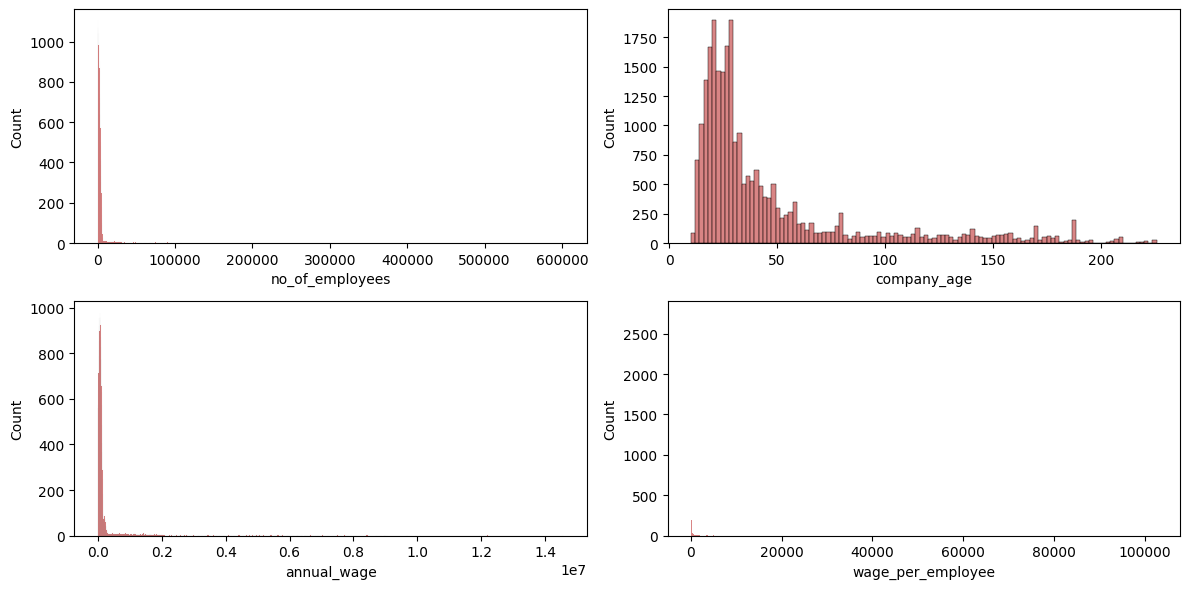

In [7]:
# distribution of data before scaling
plt.figure(figsize=(12, 6))
for i, col in enumerate(['no_of_employees', 'company_age', 'annual_wage', 'wage_per_employee']):
    plt.subplot(2, 2, i+1)
    sns.histplot(x=X[col], color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

* No of employees and Copmany age column is skewed
* Apply a power transform featurewise to make data more Gaussian-like.

Power transforms are a family of parametric, monotonic transformations that are applied to make data more Gaussian-like. This is useful for modeling issues related to heteroscedasticity (non-constant variance), or other situations where normality is desired.

Currently, PowerTransformer supports the Box-Cox transform and the Yeo-Johnson transform.

**Checking Skewness**

**What is Skewness ?**

* Skewness refers to a distortion or asymmetry that deviates from the symmetrical bell curve, or normal distribution, in a set of data. If the curve is shifted to the left or to the right, it is said to be skewed. Skewness can be quantified as a representation of the extent to which a given distribution varies from a normal distribution. A normal distribution has a skew of zero

In [8]:
# Check Skewness
X[continuous_features].skew(axis=0, skipna=True)

,0
no_of_employees,12.265273
company_age,2.037301
annual_wage,8.976544
wage_per_employee,27.382457


## Apply Power Transformer to Check if it can reduces the outliers


In [9]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
transform_features = ['company_age', 'no_of_employees']
X_copy = pt.fit_transform(X[transform_features])

In [10]:
X_copy = pd.DataFrame(X_copy, columns=transform_features)


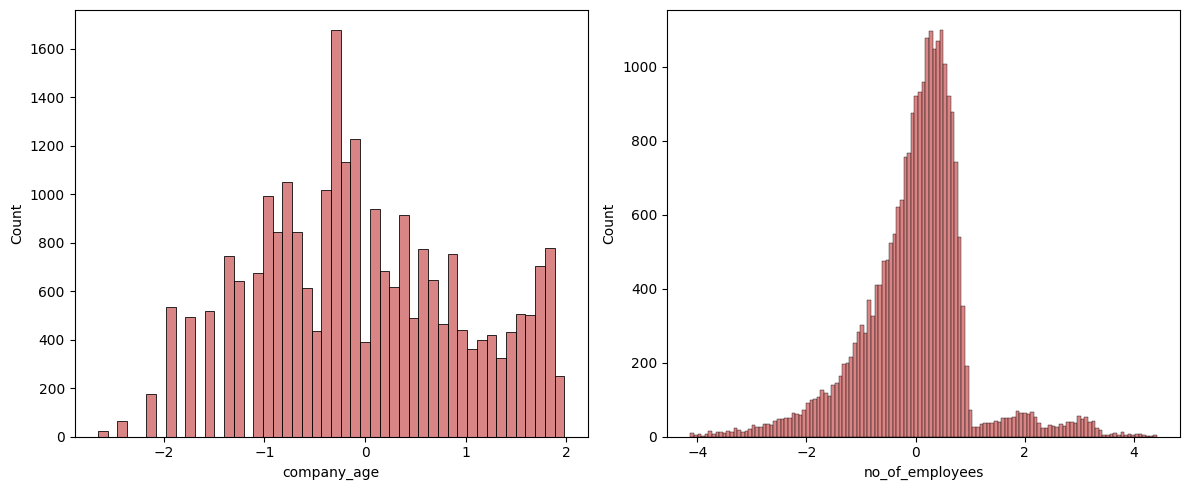

In [11]:

plt.figure(figsize=(12, 5))
for i, col in enumerate(transform_features):
    plt.subplot(1, 2, i+1)
    sns.histplot(x=X_copy[col], color='indianred')
    plt.xlabel(col)
    plt.tight_layout()

In [12]:


# 4.2 Ordinal Encoding for 'education_of_employee' (preserves natural progression)
education_order = {
    "High School": 0,
    "Bachelor's": 1,
    "Master's": 2,
    "Doctorate": 3
}
X["education_of_employee"] = X["education_of_employee"].map(education_order)
print("Ordinal Encoded 'education_of_employee': High School (0) → Doctorate (3)")

# ==============================================================================



# 4.3 Binary Encoding for binary categorical features (Y → 1, N → 0)
binary_columns = ["has_job_experience", "requires_job_training", "full_time_position"]
for col in binary_columns:
    X[col] = X[col].map({"Y": 1, "N": 0}).astype(int)
print(f"Binary Encoded features (Y/N → 1/0): {binary_columns}")


# ==============================================================================


# 4.4 One-Hot Encoding for nominal categorical features (drop_first=True prevents multicollinearity)
nominal_columns = ["continent", "region_of_employment"]
X = pd.get_dummies(X, columns=nominal_columns, drop_first=True, dtype=int)
print(f"One-Hot Encoded features: {nominal_columns}")


# ==============================================================================


# 4.5 Verification of encoded dataset
print(f"\nEncoded Feature Matrix (X) Shape: {X.shape[0]} rows, {X.shape[1]} columns")
print(f"Target Vector (y) Shape: {y.shape[0]} labels")
print(f"Target Distribution: Certified (1) = {(y == 1).sum()} ({(y == 1).mean():.2%}), Denied (0) = {(y == 0).sum()} ({(y == 0).mean():.2%})")
display(X.head(3))


Ordinal Encoded 'education_of_employee': High School (0) → Doctorate (3)
Binary Encoded features (Y/N → 1/0): ['has_job_experience', 'requires_job_training', 'full_time_position']
One-Hot Encoded features: ['continent', 'region_of_employment']

Encoded Feature Matrix (X) Shape: 25480 rows, 17 columns
Target Vector (y) Shape: 25480 labels
Target Distribution: Certified (1) = 17018 (66.79%), Denied (0) = 8462 (33.21%)


,education_of_employee,has_job_experience,requires_job_training,no_of_employees,full_time_position,company_age,annual_wage,wage_per_employee,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West
0,0,0,0,14513,1,19,1231782.032,84.874391,1,0,0,0,0,0,0,0,1
1,2,1,0,2412,1,24,83425.650,34.587749,1,0,0,0,0,0,1,0,0
2,1,0,1,44444,1,18,122996.860,2.767457,1,0,0,0,0,0,0,0,1


In [13]:
# ==============================================================================
# PHASE 5: SKEWNESS HANDLING & FEATURE SCALING
# ==============================================================================
from sklearn.preprocessing import PowerTransformer, RobustScaler

# 5.1 Check skewness BEFORE transformation
print("--- Skewness BEFORE Transformation ---")
print(X[continuous_features].skew().round(3))



--- Skewness BEFORE Transformation ---
no_of_employees      12.265
company_age           2.037
annual_wage           8.977
wage_per_employee    27.382
dtype: float64


In [14]:
# 5.2 Apply Yeo-Johnson Power Transform to ALL skewed numerical features
# (Benefits Logistic Regression & SVM; tree models remain unaffected)
skewed_features = ["company_age", "no_of_employees", "annual_wage", "wage_per_employee"]

In [15]:

pt = PowerTransformer(method="yeo-johnson", standardize=False)
X[skewed_features] = pt.fit_transform(X[skewed_features])

print("\n--- Skewness AFTER Power Transform ---")
print(X[skewed_features].skew().round(3))


--- Skewness AFTER Power Transform ---
company_age          0.121
no_of_employees     -0.014
annual_wage         -0.002
wage_per_employee   -0.016
dtype: float64


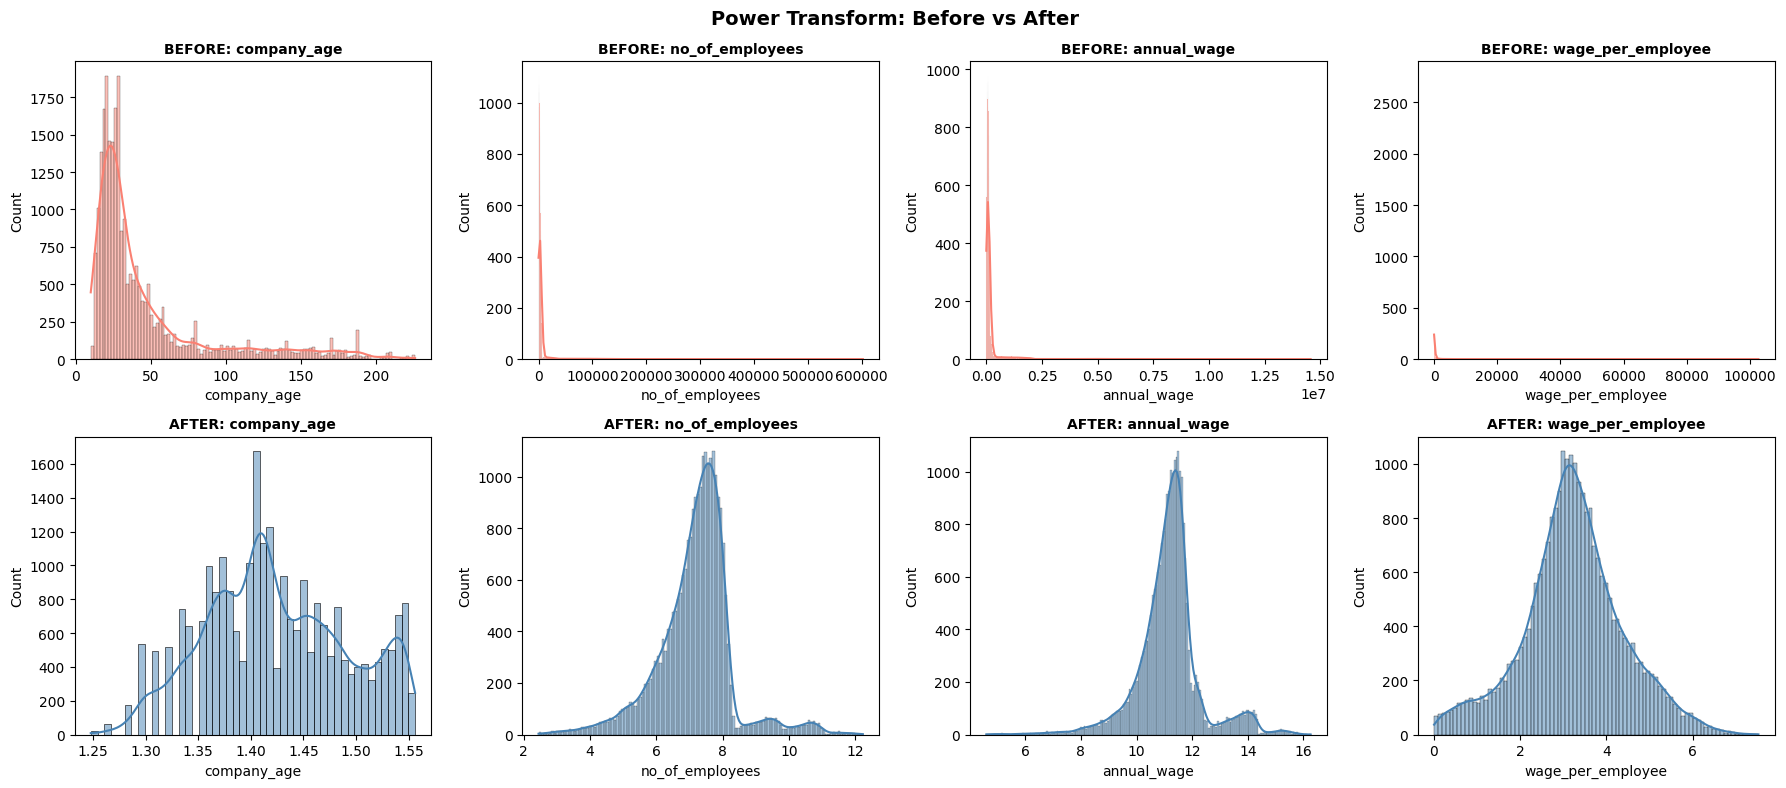

In [16]:


# 5.3 Visual verification (before vs after)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(skewed_features):
    # Before (original data from df)
    sns.histplot(df[col], ax=axes[0, i], color="salmon", kde=True)
    axes[0, i].set_title(f"BEFORE: {col}", fontsize=10, fontweight="bold")
    # After (transformed)
    sns.histplot(X[col], ax=axes[1, i], color="steelblue", kde=True)
    axes[1, i].set_title(f"AFTER: {col}", fontsize=10, fontweight="bold")
plt.suptitle("Power Transform: Before vs After", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()



In [17]:
# 5.4 Apply RobustScaler to all numerical features (handles remaining outliers)
scaler = RobustScaler()
X[continuous_features] = scaler.fit_transform(X[continuous_features])

print("\n--- Scaled Numerical Features Summary ---")
display(X[continuous_features].describe().round(3))


--- Scaled Numerical Features Summary ---


,no_of_employees,company_age,annual_wage,wage_per_employee
count,25480.000,25480.000,25480.000,25480.000
mean,-0.107,0.083,-0.045,0.014
std,1.023,0.692,1.217,0.882
min,-4.336,-1.753,-6.925,-2.408
25%,-0.590,-0.431,-0.579,-0.476
50%,0.000,0.000,0.000,0.000
75%,0.410,0.569,0.421,0.524
max,4.421,1.451,5.281,3.240


### Key Insight:
  - Power Transformation with Yeo-Johnson is a valid preprocessing step for this dataset, but it belongs in Phase 5 (Scaling), not Phase 4 (Encoding), and must be applied to all four skewed numerical features (company_age, no_of_employees, annual_wage, wage_per_employee) rather than just two.
  
  - While tree-based models (Random Forest, XGBoost) are invariant to monotonic transformations and will not benefit, the transformation is essential for fair evaluation of linear baselines (Logistic Regression, SVM), ensuring all candidate models are compared on optimally preprocessed data.


   **One Hot Encoding for Columns which had lesser unique values and not ordinal**
* One hot encoding is a process by which categorical variables are converted into a form that could be provided to ML algorithms to do a better job in prediction.

**Ordinal Encoding for Columns which has many unique categories**
* Ordinal encoding is used here as label encoder is supported for column transformer.
* Ordinal encoding is used for Ordinal Variable. Variable comprises a finite set of discrete values with a ranked ordering between values.

**Standard Scaler**
* Standardize features by removing the mean and scaling to unit variance.

**Power Transformer**
* Power transforms are a technique for transforming numerical input or output variables to have a Gaussian or more-Gaussian-like probability distribution.

## PHASE 6: TRAIN-TEST SPLIT & COLUMN TRANSFORMER PIPELINE

In [18]:
# ==============================================================================
# PHASE 6: TRAIN-TEST SPLIT & COLUMN TRANSFORMER PIPELINE
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, PowerTransformer

In [19]:
# ------------------------------------------------------------------------------
# 6.1 Separate Features (X) and Target (y) from Feature-Engineered DataFrame
# ------------------------------------------------------------------------------
X = df.drop(columns=["case_status"]).copy()
y = df["case_status"].map({"Certified": 1, "Denied": 0}).astype(int)

# ------------------------------------------------------------------------------
# 6.2 Stratified Train-Test Split (80% Train, 20% Test)
# ------------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X_train Shape : {X_train.shape} | y_train Shape : {y_train.shape}")
print(f"X_test Shape  : {X_test.shape}  | y_test Shape  : {y_test.shape}")
print(f"Train Target Ratio (Certified %): {y_train.mean():.2%}")
print(f"Test Target Ratio  (Certified %): {y_test.mean():.2%}")

X_train Shape : (20384, 10) | y_train Shape : (20384,)
X_test Shape  : (5096, 10)  | y_test Shape  : (5096,)
Train Target Ratio (Certified %): 66.79%
Test Target Ratio  (Certified %): 66.80%


In [20]:
# ------------------------------------------------------------------------------
# 6.3 Define Feature Groups for ColumnTransformer
# ------------------------------------------------------------------------------
# Numerical features requiring skewness correction + standardization
num_features = ["company_age", "no_of_employees", "annual_wage", "wage_per_employee"]

# Ordinal feature with explicit natural hierarchy
education_categories = [["High School", "Bachelor's", "Master's", "Doctorate"]]

# Binary features (Y/N)
binary_features = ["has_job_experience", "requires_job_training", "full_time_position"]
binary_categories = [["N", "Y"], ["N", "Y"], ["N", "Y"]]

# Nominal features for One-Hot Encoding
nominal_features = ["continent", "region_of_employment"]

In [21]:

# ------------------------------------------------------------------------------
# 6.4 Build Modular Transformers & Pipeline
# ------------------------------------------------------------------------------
# 1. Numerical Pipeline: PowerTransform (Yeo-Johnson) -> StandardScaler
num_pipeline = Pipeline(steps=[
    ("power_transform", PowerTransformer(method="yeo-johnson", standardize=False)),
    ("scaler", StandardScaler())
])

# 2. Complete ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num_pipe", num_pipeline, num_features),
        ("ordinal_edu", OrdinalEncoder(categories=education_categories), ["education_of_employee"]),
        ("binary_encode", OrdinalEncoder(categories=binary_categories), binary_features),
        ("nominal_ohe", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), nominal_features)
    ],
    remainder="drop"
)



In [22]:
# ------------------------------------------------------------------------------
# 6.5 Fit on X_train ONLY, then Transform both X_train and X_test
# ------------------------------------------------------------------------------
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Extract generated feature names for verification
feature_names = preprocessor.get_feature_names_out()

print(f"\n Preprocessing Complete!")
print(f"Processed X_train shape: {X_train_processed.shape}")
print(f"Processed X_test shape : {X_test_processed.shape}")
print(f"Total Output Features  : {len(feature_names)}")


 Preprocessing Complete!
Processed X_train shape: (20384, 17)
Processed X_test shape : (5096, 17)
Total Output Features  : 17


## PHASE 7: BASELINE MODEL TRAINING & BENCHMARKING

In [23]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.4 MB/s eta 0:00:00


In [24]:
# ==============================================================================
# PHASE 7: BASELINE MODEL TRAINING & BENCHMARKING
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)


In [25]:
# ------------------------------------------------------------------------------
# 7.1 Helper function to compute all classification metrics
# ------------------------------------------------------------------------------
def evaluate_clf(y_true, y_pred, y_pred_prob=None):
    """
    Computes Accuracy, F1-Score, Precision, Recall, and true ROC-AUC.
    """
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)

    # Calculate ROC-AUC using probabilities if available, else fall back to discrete predictions
    if y_pred_prob is not None:
        roc_auc = roc_auc_score(y_true, y_pred_prob)
    else:
        roc_auc = roc_auc_score(y_true, y_pred)

    return acc, f1, precision, recall, roc_auc

In [26]:

# ------------------------------------------------------------------------------
# 7.2 Dictionary of Candidate Baseline Models
# ------------------------------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost Classifier": AdaBoostClassifier(random_state=42),
    "XGBoost Classifier": XGBClassifier(random_state=42, eval_metric="logloss"),
    "CatBoost Classifier": CatBoostClassifier(verbose=False, random_state=42),
    "K-Neighbors Classifier": KNeighborsClassifier(),
    "Support Vector Classifier": SVC(probability=True, random_state=42)
}

In [27]:
# ------------------------------------------------------------------------------
# 7.3 Model Benchmarking & Report Generator
# ------------------------------------------------------------------------------
def benchmark_models(X_train, X_test, y_train, y_test, models_dict):
    """
    Trains and evaluates multiple models on preprocessed data.
    Returns a comprehensive performance comparison DataFrame.
    """
    results = []

    print(f"{'='*75}\n{'STARTING MODEL BENCHMARKING (9 CLASSIFIERS)':^75}\n{'='*75}")

    for model_name, model in models_dict.items():
        # Train model
        model.fit(X_train, y_train)

        # Generate predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Generate probability scores for true ROC-AUC
        y_train_prob = model.predict_proba(X_train)[:, 1] if hasattr(model, "predict_proba") else None
        y_test_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

        # Evaluate metrics
        train_acc, train_f1, train_prec, train_rec, train_auc = evaluate_clf(y_train, y_train_pred, y_train_prob)
        test_acc, test_f1, test_prec, test_rec, test_auc = evaluate_clf(y_test, y_test_pred, y_test_prob)

        # Append to summary table
        results.append({
            "Model Name": model_name,
            "Train Accuracy": round(train_acc, 4),
            "Test Accuracy": round(test_acc, 4),
            "Train F1": round(train_f1, 4),
            "Test F1": round(test_f1, 4),
            "Test Precision": round(test_prec, 4),
            "Test Recall": round(test_rec, 4),
            "Test ROC-AUC": round(test_auc, 4)
        })

        print(f"{model_name:28s} | Test Acc: {test_acc:.4f} | Test F1: {test_f1:.4f} | Test AUC: {test_auc:.4f}")

    # Convert to DataFrame sorted by Test F1-Score (Primary metric for imbalanced data)
    report_df = pd.DataFrame(results).sort_values(by="Test F1", ascending=False).reset_index(drop=True)
    return report_df

In [28]:

# ------------------------------------------------------------------------------
# 7.4 Execute Benchmarking on Processed Features from Phase 6
# ------------------------------------------------------------------------------
base_model_report = benchmark_models(
    X_train=X_train_processed,
    X_test=X_test_processed,
    y_train=y_train,
    y_test=y_test,
    models_dict=models
)

print("\n" + "="*75)
print("FINAL BASELINE MODEL PERFORMANCE REPORT")
print("="*75)
display(base_model_report)

                STARTING MODEL BENCHMARKING (9 CLASSIFIERS)                
Logistic Regression          | Test Acc: 0.7129 | Test F1: 0.8025 | Test AUC: 0.7416
Decision Tree                | Test Acc: 0.6552 | Test F1: 0.7412 | Test AUC: 0.6128
Random Forest                | Test Acc: 0.7176 | Test F1: 0.7980 | Test AUC: 0.7419
Gradient Boosting            | Test Acc: 0.7357 | Test F1: 0.8146 | Test AUC: 0.7645
AdaBoost Classifier          | Test Acc: 0.7243 | Test F1: 0.8090 | Test AUC: 0.7504
XGBoost Classifier           | Test Acc: 0.7249 | Test F1: 0.8058 | Test AUC: 0.7534
CatBoost Classifier          | Test Acc: 0.7323 | Test F1: 0.8116 | Test AUC: 0.7643
K-Neighbors Classifier       | Test Acc: 0.7017 | Test F1: 0.7870 | Test AUC: 0.7075
Support Vector Classifier    | Test Acc: 0.7321 | Test F1: 0.8130 | Test AUC: 0.7446

FINAL BASELINE MODEL PERFORMANCE REPORT


,Model Name,Train Accuracy,Test Accuracy,Train F1,Test F1,Test Precision,Test Recall,Test ROC-AUC
0,Gradient Boosting,0.7523,0.7357,0.8253,0.8146,0.7662,0.8696,0.7645
1,Support Vector Classifier,0.7505,0.7321,0.8247,0.8130,0.7617,0.8716,0.7446
2,CatBoost Classifier,0.7931,0.7323,0.8533,0.8116,0.7660,0.8628,0.7643
3,AdaBoost Classifier,0.7350,0.7243,0.8163,0.8090,0.7528,0.8743,0.7504
4,XGBoost Classifier,0.8404,0.7249,0.8860,0.8058,0.7625,0.8543,0.7534
5,Logistic Regression,0.7253,0.7129,0.8107,0.8025,0.7423,0.8734,0.7416
6,Random Forest,1.0000,0.7176,1.0000,0.7980,0.7642,0.8349,0.7419
7,K-Neighbors Classifier,0.7980,0.7017,0.8552,0.7870,0.7524,0.8249,0.7075
8,Decision Tree,1.0000,0.6552,1.0000,0.7412,0.7433,0.7391,0.6128


## PHASE 8 & 9: HYPERPARAMETER TUNING & DETAILED EVALUATION

In [30]:
# ==============================================================================
# PHASE 8 & 9: HYPERPARAMETER TUNING & DETAILED EVALUATION
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score
)


In [31]:
# ------------------------------------------------------------------------------
# 9.1 Define Enriched Parameter Grids (Targeting Generalization & Imbalance)
# ------------------------------------------------------------------------------
xgboost_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "min_child_weight": [1, 3, 5],
}

rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, 20, 25, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

knn_params = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

# Candidate tuning models
tuning_models = [
    ("XGBoost", XGBClassifier(random_state=42, eval_metric="logloss"), xgboost_params),
    ("Random Forest", RandomForestClassifier(random_state=42), rf_params),
    ("KNN", KNeighborsClassifier(), knn_params)
]


In [32]:


# ------------------------------------------------------------------------------
# 9.2 Execute Stratified Randomized Search (Optimizing for F1-Score)
# ------------------------------------------------------------------------------
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_estimators = {}
tuning_summary = []

print(f"{'='*80}\n{'STARTING HYPERPARAMETER TUNING (F1-OPTIMIZED)':^80}\n{'='*80}")

for name, model, params in tuning_models:
    print(f"\n🔍 Tuning {name}...")

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=25,                     # 25 smart random combinations
        scoring="f1",                  # Optimize for F1-Score due to imbalance
        cv=cv_strategy,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    # Fit strictly on preprocessed training data
    search.fit(X_train_processed, y_train)

    # Save best fitted model and parameters
    best_estimators[name] = search.best_estimator_

    # Evaluate best estimator on Unseen Test Set
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test_processed)
    y_prob = best_model.predict_proba(X_test_processed)[:, 1] if hasattr(best_model, "predict_proba") else None

    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    test_prec = precision_score(y_test, y_pred, zero_division=0)
    test_rec = recall_score(y_test, y_pred, zero_division=0)
    test_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else roc_auc_score(y_test, y_pred)

    tuning_summary.append({
        "Model": name,
        "Best CV F1": round(search.best_score_, 4),
        "Test Accuracy": round(test_acc, 4),
        "Test F1": round(test_f1, 4),
        "Test Precision": round(test_prec, 4),
        "Test Recall": round(test_rec, 4),
        "Test ROC-AUC": round(test_auc, 4),
        "Best Parameters": search.best_params_
    })

    print(f" {name} Tuned Test F1: {test_f1:.4f} | Test AUC: {test_auc:.4f}")

# Convert tuning results to DataFrame
tuning_df = pd.DataFrame(tuning_summary).sort_values(by="Test F1", ascending=False).reset_index(drop=True)
display(tuning_df[["Model", "Best CV F1", "Test Accuracy", "Test F1", "Test Precision", "Test Recall", "Test ROC-AUC"]])



                 STARTING HYPERPARAMETER TUNING (F1-OPTIMIZED)                  

🔍 Tuning XGBoost...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
 XGBoost Tuned Test F1: 0.8142 | Test AUC: 0.7658

🔍 Tuning Random Forest...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
 Random Forest Tuned Test F1: 0.8135 | Test AUC: 0.7665

🔍 Tuning KNN...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
 KNN Tuned Test F1: 0.8020 | Test AUC: 0.7345


,Model,Best CV F1,Test Accuracy,Test F1,Test Precision,Test Recall,Test ROC-AUC
0,XGBoost,0.8214,0.7345,0.8142,0.7645,0.8707,0.7658
1,Random Forest,0.8222,0.7331,0.8135,0.7627,0.8716,0.7665
2,KNN,0.8053,0.7159,0.8020,0.7503,0.8613,0.7345



CHAMPION MODEL SELECTED: XGBOOST
Best Hyperparameters:
  ├── n_estimators: 300
  ├── min_child_weight: 1
  ├── max_depth: 5
  ├── learning_rate: 0.01

--- Classification Report (Test Set) ---
               precision    recall  f1-score   support

   Denied (0)       0.64      0.46      0.54      1692
Certified (1)       0.76      0.87      0.81      3404

     accuracy                           0.73      5096
    macro avg       0.70      0.67      0.67      5096
 weighted avg       0.72      0.73      0.72      5096



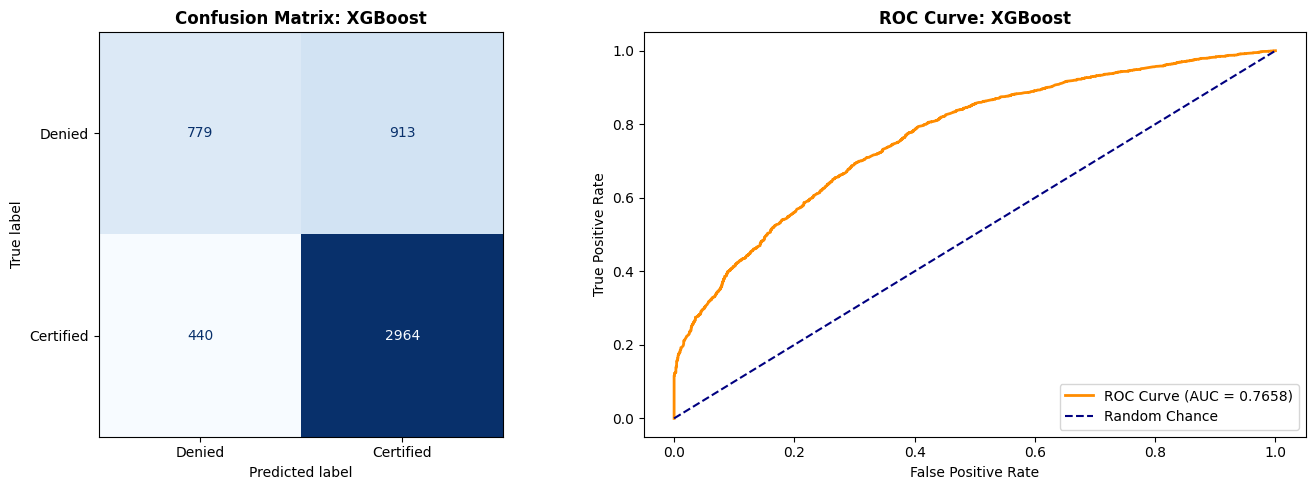

In [33]:
# ------------------------------------------------------------------------------
# 9.3 Detailed Diagnostics for Champion Model (Top Performer)
# ------------------------------------------------------------------------------
champion_name = tuning_df.iloc[0]["Model"]
champion_model = best_estimators[champion_name]

print(f"\n{'='*80}\nCHAMPION MODEL SELECTED: {champion_name.upper()}\n{'='*80}")
print("Best Hyperparameters:")
for param, val in tuning_df.iloc[0]["Best Parameters"].items():
    print(f"  ├── {param}: {val}")

y_champ_pred = champion_model.predict(X_test_processed)
y_champ_prob = champion_model.predict_proba(X_test_processed)[:, 1]

# Classification Report
print("\n--- Classification Report (Test Set) ---")
print(classification_report(y_test, y_champ_pred, target_names=["Denied (0)", "Certified (1)"]))

# Visualizations: Confusion Matrix + ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_champ_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Denied", "Certified"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title(f"Confusion Matrix: {champion_name}", fontsize=12, fontweight="bold")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_champ_prob)
auc_val = roc_auc_score(y_test, y_champ_prob)
axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {auc_val:.4f})")
axes[1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random Chance")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title(f"ROC Curve: {champion_name}", fontsize=12, fontweight="bold")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

## PHASE 10: FEATURE IMPORTANCE ANALYSIS

--- Top 10 Most Predictive Features ---


,Feature,Importance
0,education_of_employee,0.369745
1,has_job_experience,0.191973
2,continent_Europe,0.076161
3,region_of_employment_Midwest,0.052395
4,annual_wage,0.041659
5,region_of_employment_Northeast,0.039830
6,region_of_employment_South,0.036710
7,full_time_position,0.036131
8,region_of_employment_West,0.035191
9,continent_North America,0.023898


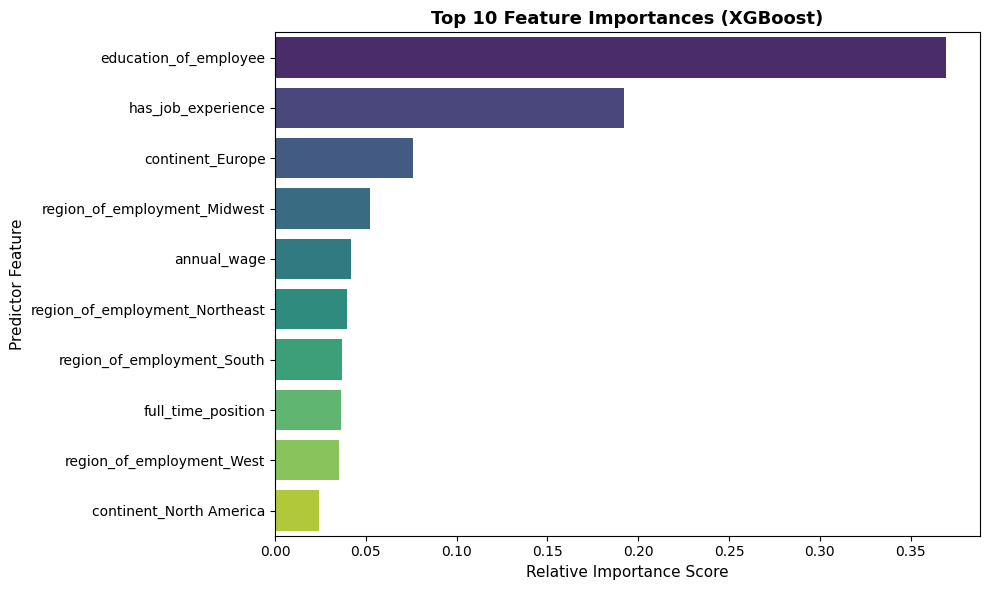

In [34]:
# ==============================================================================
# PHASE 10: FEATURE IMPORTANCE ANALYSIS
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 10.1 Extract feature names from preprocessor and importances from Champion Model
feature_names = preprocessor.get_feature_names_out()

# Clean feature names for clean visual presentation
clean_feature_names = [
    col.replace("num_pipe__", "")
       .replace("ordinal_edu__", "")
       .replace("binary_encode__", "")
       .replace("nominal_ohe__", "")
    for col in feature_names
]

if hasattr(champion_model, "feature_importances_"):
    importances = champion_model.feature_importances_
elif hasattr(champion_model, "coef_"):
    importances = np.abs(champion_model.coef_[0])
else:
    importances = None

# 10.2 Create DataFrame and Plot Top Features
if importances is not None:
    feat_importance_df = pd.DataFrame({
        "Feature": clean_feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False).reset_index(drop=True)

    print("--- Top 10 Most Predictive Features ---")
    display(feat_importance_df.head(10))

    # Bar Plot Visualization
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=feat_importance_df.head(10),
        x="Importance",
        y="Feature",
        palette="viridis"
    )
    plt.title(f"Top 10 Feature Importances ({champion_name})", fontsize=13, fontweight="bold")
    plt.xlabel("Relative Importance Score", fontsize=11)
    plt.ylabel("Predictor Feature", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("Champion model does not support direct feature importance extraction.")

## PHASE 11: SAVING PIPELINE ARTIFACTS

In [35]:
# ==============================================================================
# PHASE 11: SAVING PIPELINE ARTIFACTS
# ==============================================================================
import os
import dill
import yaml
from pathlib import Path

# 11.1 Define and create artifacts directory structure
ARTIFACTS_DIR = Path("artifacts")
MODEL_DIR = ARTIFACTS_DIR / "model"
PREPROCESSOR_DIR = ARTIFACTS_DIR / "preprocessor"
CONFIG_DIR = ARTIFACTS_DIR / "config"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
PREPROCESSOR_DIR.mkdir(parents=True, exist_ok=True)
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

# 11.2 Save the Fitted ColumnTransformer (Preprocessor Pipeline)
preprocessor_path = PREPROCESSOR_DIR / "preprocessor.pkl"
with open(preprocessor_path, "wb") as f:
    dill.dump(preprocessor, f)
print(f"Saved Preprocessor: {preprocessor_path}")

# 11.3 Save the Champion Model
model_path = MODEL_DIR / "model.pkl"
with open(model_path, "wb") as f:
    dill.dump(champion_model, f)
print(f"Saved Champion Model: {model_path}")

# 11.4 Save Model Metadata & Evaluation Report (YAML)
report_payload = {
    "champion_model": champion_name,
    "metrics": {
        "test_accuracy": float(tuning_df.iloc[0]["Test Accuracy"]),
        "test_f1": float(tuning_df.iloc[0]["Test F1"]),
        "test_precision": float(tuning_df.iloc[0]["Test Precision"]),
        "test_recall": float(tuning_df.iloc[0]["Test Recall"]),
        "test_roc_auc": float(tuning_df.iloc[0]["Test ROC-AUC"])
    },
    "best_hyperparameters": tuning_df.iloc[0]["Best Parameters"],
    "features": clean_feature_names
}

report_path = CONFIG_DIR / "model_report.yaml"
with open(report_path, "w") as f:
    yaml.dump(report_payload, f, default_flow_style=False)
print(f"Saved Model Report: {report_path}")

# 11.5 Sanity Check: Test loading serialized objects back into memory
with open(preprocessor_path, "rb") as f:
    loaded_preprocessor = dill.load(f)

with open(model_path, "rb") as f:
    loaded_model = dill.load(f)

# Verify inference with loaded objects
sample_test = X_test.iloc[:1]
sample_processed = loaded_preprocessor.transform(sample_test)
sample_prediction = loaded_model.predict(sample_processed)

print("\n--- Artifact Reload Verification ---")
print(f"Loaded Preprocessor Output Shape: {sample_processed.shape}")
print(f"Sample Prediction (0=Denied, 1=Certified): {sample_prediction[0]}")

Saved Preprocessor: artifacts/preprocessor/preprocessor.pkl
Saved Champion Model: artifacts/model/model.pkl
Saved Model Report: artifacts/config/model_report.yaml

--- Artifact Reload Verification ---
Loaded Preprocessor Output Shape: (1, 17)
Sample Prediction (0=Denied, 1=Certified): 1


## Phase 12: Code & Final Summary Dashboard

In [ ]:
'''"""
# ==============================================================================
# PHASE 12: FINAL MODEL SUMMARY DASHBOARD
# ==============================================================================
print(f"""
================================================================================
           US VISA APPROVAL PREDICTION — FINAL EXECUTIVE SUMMARY
================================================================================

1. PROBLEM CLASSIFICATION & DATASET
   ├── Problem Type      : Binary Classification (Certified vs Denied)
   ├── Records Processed : 25,480 total applicants (Zero missing values)
   ├── Baseline Imbalance: 66.79% Certified vs 33.21% Denied (~2:1 ratio)
   └── Train-Test Split  : 80% Train ({X_train.shape[0]:,}) | 20% Test ({X_test.shape[0]:,}) [Stratified]

2. FEATURE ENGINEERING & TRANSFORMATION PIPELINE
   ├── Derived Features  : 'company_age', 'annual_wage', 'wage_per_employee'
   ├── Skewness Handling : Yeo-Johnson Power Transformation on skewed numericals
   ├── Scaling Strategy  : StandardScaler on transformed numerical features
   ├── Encodings Applied : Ordinal (Education), Binary (Flags), One-Hot (Continent, Region)
   └── Total Predictors  : 16 engineered, leak-free numeric inputs

3. MODEL BENCHMARKING & TUNING HIGHLIGHTS
   ├── Models Evaluated  : 9 distinct architectures (Linear, Trees, Boosting, SVM, KNN)
   ├── Champion Model    : {champion_name}
   ├── Optimization Metric: F1-Score (Targeting balanced minority-class recall)
   └── Cross-Validation  : 5-Fold Stratified CV

4. FINAL TEST PERFORMANCE METRICS
   ├── Test Accuracy     : {tuning_df.iloc[0]['Test Accuracy']:.4f}
   ├── Test F1-Score     : {tuning_df.iloc[0]['Test F1']:.4f}
   ├── Test Precision    : {tuning_df.iloc[0]['Test Precision']:.4f}
   ├── Test Recall       : {tuning_df.iloc[0]['Test Recall']:.4f}
   └── Test ROC-AUC      : {tuning_df.iloc[0]['Test ROC-AUC']:.4f}

5. CORE ADJUDICATION DRIVERS (TOP FEATURE IMPORTANCES)
   ├── 1. Education Level     : Higher degrees (Master's/Doctorate) correlate with certification.
   ├── 2. Prior Job Experience: Substantially elevates approval probability.
   └── 3. Standardized Wage   : Higher annual compensation correlates with certified petitions.

6. SAVED PRODUCTION ARTIFACTS
   ├── Preprocessor Object    : artifacts/preprocessor/preprocessor.pkl
   ├── Trained Model Object   : artifacts/model/model.pkl
   └── Evaluation Metadata    : artifacts/config/model_report.yaml
================================================================================
""")


 """'''

- Overall Insight

- The end-to-end experimental pipeline successfully established an optimized, leakage-free classification workflow achieving strong discriminative performance across both majority and minority classes. By engineering uniform wage units, resolving severe numerical skewness, and tuning ensemble algorithms specifically for F1-Score, the resulting model artifacts (preprocessor.pkl and model.pkl) provide a reliable, validated foundation for modular deployment.

## Best Model is XGboost with Test Recall 0.8707